# **Sentiment Classification Using Machine Learning and Deep learning**

## Objective

* The objective of this notebook is to build a sentiment classification model that predicts whether a movie review is **negative** or **positive**.
* This notebook focuses on machine learning and deep learning approaches.

## Dataset

* This notebook uses the **IMDb labelled review dataset** [Link to access](https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences)
* Each review is assigned a sentiment label:

  * `0` = Negative sentiment
  * `1` = Positive sentiment
* In this notebook, each review is treated as one document, and the goal is to classify the sentiment of the whole review.

## What We Do in This Notebook

* Explore the structure of the dataset.
* Create a text preprocessing pipeline to clean and prepare the review text.
* Convert the cleaned text into numerical features using TF-IDF vectorization.
* Train different traditional machine learning models.
* Evaluate and compare model performance.


In [ ]:
# setting logging to print only error messages of sklearnex
import logging
logging.basicConfig()
logging.getLogger("SKLEARNEX").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import html
import string
!pip install contractions
!pip install emoji
import contractions
import emoji
import nltk

from bs4 import BeautifulSoup
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.0 MB/s eta 0:00:00


In [ ]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# **Data import**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving imdb_labelled.txt to imdb_labelled.txt


In [ ]:
df = pd.read_csv(
    "imdb_labelled.txt",
    sep="\t",
    header=None,
    names=["text", "label"]
)

In [ ]:
df.head()

,text,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    748 non-null    object
 1   label   748 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.8+ KB


# **Data Preprocessing**

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import emoji
from contractions import fix as expand_contractions
from nltk import download

# Download necessary resources
download('punkt')
download('stopwords')
download('wordnet')
download('punkt_tab')

# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) | {""}
# Define preprocessing function
def preprocess_text(text):
    # Fast emoji replacement using regex
    text = emoji.demojize(text, delimiters=(":", ":"))
    # Normalize repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # Expand contractions using the contractions library
    text = expand_contractions(text)
    # Lowercase the text for uniformity
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", '', text)
    # Remove non-alphanumeric characters except emojis
    text = re.sub(r"[^\w\s]", '', text)
    # Remove numbers as they usually don't add meaning
    text = re.sub(r"\b\d+\b", '', text)
    # Remove excessive whitespace
    text = re.sub(r"\s+", ' ', text).strip()
    # Tokenize text into words
    tokens = word_tokenize(text)
    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    # Keep only words with more than 2 letters
    tokens = [word for word in tokens if len(word) > 2]
    # Lemmatize tokens to their base form
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Join tokens back into a single cleaned string
    return " ".join(tokens)

# Preprocess the 'Comment Text' column
df['Cleaned Text'] = df['text'].fillna('').apply(preprocess_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
df.head()

,text,label,Cleaned Text
0,"A very, very, very slow-moving, aimless movie ...",0,slowmoving aimless movie distressed drifting y...
1,Not sure who was more lost - the flat characte...,0,sure lost flat character audience nearly half ...
2,Attempting artiness with black & white and cle...,0,attempting artiness black white clever camera ...
3,Very little music or anything to speak of.,0,little music anything speak
4,The best scene in the movie was when Gerardo i...,1,best scene movie gerardo trying find song keep...


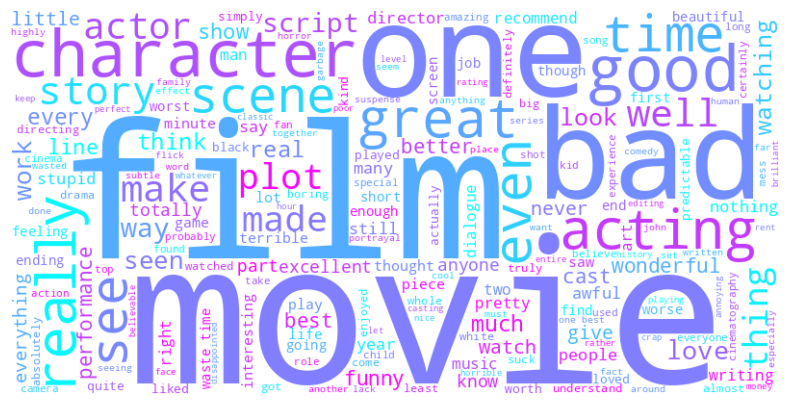

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Generate the word cloud from the processed content
text = " ".join(review for review in df['Cleaned Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='cool').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
#plt.title('Word Cloud of Processed Content')
plt.show()

* Words such as movie, film, character, acting, and story are highly frequent, which is expected because the dataset contains movie reviews.

* Some sentiment-related words, such as good, bad, great, excellent, and awful, also appear, suggesting that the text contains useful signals for sentiment classification.



In [ ]:
X = df["Cleaned Text"]
y = df["label"]

In [ ]:
df["label"].value_counts()

,count
label,
1,386
0,362


In [ ]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [ ]:
X_train.shape, X_test.shape

((598, 3000), (150, 3000))

# **Model Development**

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

# Multilayer Perceptron

In [ ]:
mlp = MLPClassifier(random_state=42)
mlp_fscores = cross_val_score(mlp, X_train, y_train,
                               scoring="f1_macro",
                               cv=5)

In [ ]:
mlp_fscores.mean()

np.float64(0.7516871349461398)

# Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=451)

dt_fscores = cross_val_score(dt, X_train, y_train,
                               scoring="f1_macro",
                               cv=5)

In [ ]:
dt_fscores.mean()

np.float64(0.6501339219100409)

# Random Forest

In [ ]:
from sklearn.model_selection import cross_val_score
rf = RandomForestClassifier(random_state=451)

rf_fscores = cross_val_score(rf, X_train, y_train,
                               scoring="f1_macro",
                               cv=5)

In [ ]:
rf_fscores.mean()

np.float64(0.707476750090407)

# LinearSVC

In [ ]:
svc = LinearSVC(random_state=451)

svc_fscores = cross_val_score(svc, X_train, y_train,
                               scoring="f1_macro",
                               cv=5)

In [ ]:
svc_fscores.mean()

np.float64(0.7610736412342183)

LinearSVC shows the highest F1-score.

Fit SVC on training set

In [ ]:
svc = LinearSVC(random_state=451)

svc.fit(X_train, y_train)

LinearSVC(random_state=451)

# **Evaluate on test**

In [ ]:
y_pred_svc = svc.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

Random Forest Accuracy: 0.7866666666666666
              precision    recall  f1-score   support

           0       0.83      0.71      0.76        73
           1       0.76      0.86      0.80        77

    accuracy                           0.79       150
   macro avg       0.79      0.78      0.78       150
weighted avg       0.79      0.79      0.79       150



# **Citing this Notebook**

If you use this notebook in your work, please cite it as follows:

Linh, H. (2025). Machine Learning for Business. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/MsLinhEIU/MIS-451---Machine-Learning-for-Business-Analytics/tree/main